In [1]:
# ============================================================
# Entrega 3 — Implementación, Resultados y Conclusiones
# Proyecto: ¿Influyen los cómics de Marvel en los nombres?
# Autor: Juan Sebastián Cruz Rojas
# ============================================================

import os, sys, warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import unicodedata

sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
from utils import (
    extract_year_from_appearance,
    normalize_name,
    wide_to_long_marvel,
    load_ssa,
    cross_lag_correlation,
    get_ssa_name_freq_by_year
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_RAW  = os.path.join('..', 'data', 'raw')
DATA_PROC = os.path.join('..', 'data', 'processed')
os.makedirs(DATA_PROC, exist_ok=True)

print('Configuración lista.')

Configuración lista.


In [2]:
# ── Cargar datasets procesados de la entrega 2 ──────────────
marvel_raw = pd.read_csv(os.path.join(DATA_RAW, 'marvel_comics_legacy.csv'), index_col=0)
marvel_long = wide_to_long_marvel(marvel_raw)
marvel_long = marvel_long.drop_duplicates()
marvel_long = marvel_long[(marvel_long['year'] >= 1939) & (marvel_long['year'] <= 2023)]
marvel_long['first_name'] = (
    marvel_long['character']
    .str.extract(r'^([A-Za-zÀ-ÿ]+)', expand=False)
    .apply(normalize_name)
)
marvel_by_year = (
    marvel_long
    .groupby(['character', 'first_name', 'year'])
    .size()
    .reset_index(name='appearances')
)

ssa_df = load_ssa(os.path.join(DATA_RAW, 'ssa'), year_start=1939, year_end=2023)
ssa_df['name_norm'] = ssa_df['name'].apply(normalize_name)
ssa_by_year = (
    ssa_df.groupby(['name_norm', 'year'])['count']
    .sum().reset_index()
    .rename(columns={'count': 'total_births'})
)

colombia_df = pd.read_csv(os.path.join(DATA_RAW, 'colombia_nombres.csv'))
colombia_df['name_norm'] = colombia_df['name'].apply(normalize_name)

print(f'Marvel: {len(marvel_long):,} apariciones')
print(f'SSA: {len(ssa_by_year):,} registros (nombre, año)')
print(f'Colombia: {len(colombia_df)} registros')

Marvel: 15,354 apariciones
SSA: 1,611,029 registros (nombre, año)
Colombia: 82 registros


In [3]:
# ── Cargar dataset FIFA — Futbolistas colombianos ────────────
fifa_files = {
    2015: 'players_15.csv',
    2016: 'players_16.csv',
    2017: 'players_17.csv',
    2018: 'players_18.csv',
    2019: 'players_19.csv',
    2020: 'players_20.csv',
}

fifa_dfs = []
for year, fname in fifa_files.items():
    fpath = os.path.join(DATA_RAW, 'fifa', fname)
    df = pd.read_csv(fpath,
                     usecols=['short_name', 'long_name', 'nationality', 'overall'],
                     low_memory=False)
    df['fifa_year'] = year
    fifa_dfs.append(df)

fifa_all = pd.concat(fifa_dfs, ignore_index=True)

# Filtrar colombianos
colombia_players = fifa_all[fifa_all['nationality'] == 'Colombia'].copy()

# Extraer primer nombre normalizado
colombia_players['first_name'] = (
    colombia_players['long_name']
    .str.extract(r'^([A-Za-zÀ-ÿ]+)', expand=False)
    .apply(normalize_name)
)

# Top jugadores por overall máximo
top_col = (
    colombia_players
    .groupby(['long_name', 'first_name'])['overall']
    .max()
    .reset_index()
    .sort_values('overall', ascending=False)
    .head(20)
)

print(f'Jugadores colombianos únicos en FIFA 15-20: {colombia_players["long_name"].nunique()}')
print(f'\nTop 20 por overall:')
print(top_col[['long_name', 'first_name', 'overall']].to_string(index=False))

Jugadores colombianos únicos en FIFA 15-20: 1244

Top 20 por overall:
                     long_name first_name  overall
   James David Rodríguez Rubio      James       88
  Radamel Falcao García Zárate    Radamel       88
              Jackson Martínez    Jackson       84
              Davinson Sánchez   Davinson       84
   Carlos Arturo Bacca Ahumada     Carlos       84
                 Juan Cuadrado       Juan       84
                  Duván Zapata      Duvan       82
   Jeison Fabián Murillo Cerón     Jeison       81
Fredy Alejandro Guarín Vásquez      Fredy       80
    Luis Fernando Muriel Fruto       Luis       80
          David Ospina Ramírez      David       80
        Juan Fernando Quintero       Juan       80
  Gustavo Adrián Ramos Vásquez    Gustavo       79
        Santiago Arias Naranjo   Santiago       79
  Jefferson Andrés Lerma Solís  Jefferson       79
             Teófilo Gutiérrez    Teofilo       79
     Pedro Camilo Franco Ulloa      Pedro       78
   Fredy Hen

In [4]:
# ── Cruce: primeros nombres de futbolistas colombianos top
#    vs top de nombres en Colombia (Registraduría) ────────────

# Top 30 futbolistas por overall para análisis
top30_players = (
    colombia_players
    .groupby(['long_name', 'first_name'])['overall']
    .max()
    .reset_index()
    .sort_values('overall', ascending=False)
    .head(30)
)

# Nombres únicos de futbolistas top
futbolistas_names = set(top30_players['first_name'].str.lower().dropna())

# Nombres en top Colombia
colombia_names = set(colombia_df['name_norm'].str.lower().dropna())

# Cruce
en_comun = futbolistas_names & colombia_names
print('Nombres en común (futbolistas top vs top Colombia):')
print(en_comun if en_comun else 'Ninguno en común directamente')

print()

# Ver qué nombres de futbolistas aparecen en SSA (para cadena completa)
en_ssa = futbolistas_names & set(ssa_by_year['name_norm'].str.lower().dropna())
print(f'Nombres de futbolistas colombianos top que aparecen en SSA: {len(en_ssa)}')
print(sorted(en_ssa))

print()
# Frecuencia de nombres de futbolistas en Colombia
print('Nombres de futbolistas colombianos en el top Colombia:')
for name in sorted(futbolistas_names):
    match = colombia_df[colombia_df['name_norm'].str.lower() == name]
    if len(match) > 0:
        print(f'  {name.title()}: aparece en {match["year"].tolist()}')

Nombres en común (futbolistas top vs top Colombia):
{'santiago'}

Nombres de futbolistas colombianos top que aparecen en SSA: 25
['alexander', 'bernardo', 'carlos', 'cristian', 'david', 'duvan', 'edgar', 'frank', 'fredy', 'giovanni', 'gustavo', 'jackson', 'james', 'jefferson', 'jeison', 'johan', 'jose', 'juan', 'luis', 'pedro', 'radamel', 'santiago', 'segundo', 'teofilo', 'wilmar']

Nombres de futbolistas colombianos en el top Colombia:
  Santiago: aparece en [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [6]:
# ── Bootstrap temporal corregido ─────────────────────────────
np.random.seed(42)
N_BOOTSTRAP = 1000
BLOCK_SIZE = 5

def bootstrap_lag_correlation(series_a, series_b, lag, n_boot=1000, block_size=5):
    b_shifted = series_b.shift(-lag)
    combined = pd.DataFrame({'a': series_a, 'b': b_shifted}).dropna()
    
    if len(combined) < 10:
        return np.nan, np.nan, np.nan
    
    real_corr, _ = stats.pearsonr(combined['a'], combined['b'])
    
    n = len(combined)
    n_blocks = int(np.ceil(n / block_size))
    boot_corrs = []
    
    for _ in range(n_boot):
        indices = []
        for _ in range(n_blocks):
            start = np.random.randint(0, n - block_size + 1)
            indices.extend(range(start, start + block_size))
        indices = indices[:n]
        sample = combined.iloc[indices]
        if sample['a'].std() == 0 or sample['b'].std() == 0:
            continue
        c, _ = stats.pearsonr(sample['a'], sample['b'])
        boot_corrs.append(c)
    
    # CORRECCIÓN: verificar que hay suficientes muestras bootstrap
    if len(boot_corrs) < 10:
        return real_corr, np.nan, np.nan
    
    ic_lower = np.percentile(boot_corrs, 2.5)
    ic_upper = np.percentile(boot_corrs, 97.5)
    return real_corr, ic_lower, ic_upper

results_bootstrap = []

for name, lag in [('Thor', 4), ('Logan', 3), ('Wanda', 3), ('Peter', 2), ('Carol', 4), ('Tony', 5)]:
    marvel_s = (
        marvel_by_year[marvel_by_year['first_name'].str.lower() == name.lower()]
        .groupby('year')['appearances'].sum()
        .reindex(range(1939, 2024), fill_value=0)
    )
    ssa_s = get_ssa_name_freq_by_year(ssa_df, name).reindex(range(1939, 2024), fill_value=0)
    
    r, ic_low, ic_high = bootstrap_lag_correlation(marvel_s, ssa_s, lag=lag)
    
    if np.isnan(ic_low):
        sig = 'Sin datos'
        label = '— sin datos suficientes'
    else:
        sig = 'Sí' if ic_low > 0 or ic_high < 0 else 'No'
        label = '✓ significativo' if sig == 'Sí' else '✗ no significativo'
    
    results_bootstrap.append({
        'Nombre': name,
        'Rezago': f'{lag} años',
        'r real': round(r, 3) if not np.isnan(r) else '—',
        'IC 95% inf': round(ic_low, 3) if not np.isnan(ic_low) else '—',
        'IC 95% sup': round(ic_high, 3) if not np.isnan(ic_high) else '—',
        'Significativo': sig
    })
    print(f'{name} (lag={lag}): r={r:.3f}, IC=[{ic_low}, {ic_high}] → {label}')

boot_df = pd.DataFrame(results_bootstrap)
print('\nResumen:')
print(boot_df.to_string(index=False))

Thor (lag=4): r=0.534, IC=[0.24171388811610042, 0.6790670358762216] → ✓ significativo
Logan (lag=3): r=0.386, IC=[0.2379287410999593, 0.5328182668826] → ✓ significativo
Wanda (lag=3): r=nan, IC=[nan, nan] → — sin datos suficientes
Peter (lag=2): r=-0.082, IC=[-0.28569440735120544, 0.1708505685552677] → ✗ no significativo
Carol (lag=4): r=-0.122, IC=[-0.20177680272947882, -0.06591075206390307] → ✓ significativo
Tony (lag=5): r=-0.175, IC=[-0.2751581606695244, -0.05770935298700666] → ✓ significativo

Resumen:
Nombre Rezago r real IC 95% inf IC 95% sup Significativo
  Thor 4 años  0.534      0.242      0.679            Sí
 Logan 3 años  0.386      0.238      0.533            Sí
 Wanda 3 años      —          —          —     Sin datos
 Peter 2 años -0.082     -0.286      0.171            No
 Carol 4 años -0.122     -0.202     -0.066            Sí
  Tony 5 años -0.175     -0.275     -0.058            Sí


In [7]:
# ── Análisis: Futbolistas colombianos top vs nombres Colombia ─

# Primeros nombres de los top 15 futbolistas colombianos
top15_names = (
    colombia_players
    .groupby(['long_name', 'first_name'])['overall']
    .max()
    .reset_index()
    .sort_values('overall', ascending=False)
    .head(15)['first_name']
    .dropna()
    .unique()
)

print('Primeros nombres analizados:', list(top15_names))
print()

# Para cada nombre, ver si aparece en el top Colombia por año
# y en qué ranking
results_futbol = []
for name in top15_names:
    col_match = colombia_df[colombia_df['name_norm'].str.lower() == name.lower()]
    in_colombia = len(col_match) > 0
    years_in_top = col_match['year'].tolist() if in_colombia else []
    avg_rank = col_match['rank'].mean() if in_colombia and 'rank' in col_match.columns else None
    
    results_futbol.append({
        'Nombre': name,
        'En top Colombia': 'Sí' if in_colombia else 'No',
        'Años en top': len(years_in_top),
        'Ranking promedio': round(avg_rank, 1) if avg_rank else '—',
        'Años': years_in_top[:3]
    })

futbol_df = pd.DataFrame(results_futbol)
print('Nombres de futbolistas colombianos top en Registraduría:')
print(futbol_df[['Nombre','En top Colombia','Años en top','Ranking promedio']].to_string(index=False))

# Gráfico: popularidad de Santiago en Colombia por año
print()
santiago_col = colombia_df[colombia_df['name_norm'].str.lower() == 'santiago'].sort_values('year')
print('Santiago en top Colombia:')
print(santiago_col[['year','rank']].to_string(index=False))

Primeros nombres analizados: ['James', 'Radamel', 'Jackson', 'Davinson', 'Carlos', 'Juan', 'Duvan', 'Jeison', 'Fredy', 'Luis', 'David', 'Gustavo', 'Santiago', 'Jefferson']

Nombres de futbolistas colombianos top en Registraduría:
   Nombre En top Colombia  Años en top Ranking promedio
    James              No            0                —
  Radamel              No            0                —
  Jackson              No            0                —
 Davinson              No            0                —
   Carlos              No            0                —
     Juan              No            0                —
    Duvan              No            0                —
   Jeison              No            0                —
    Fredy              No            0                —
     Luis              No            0                —
    David              No            0                —
  Gustavo              No            0                —
 Santiago              Sí            9    

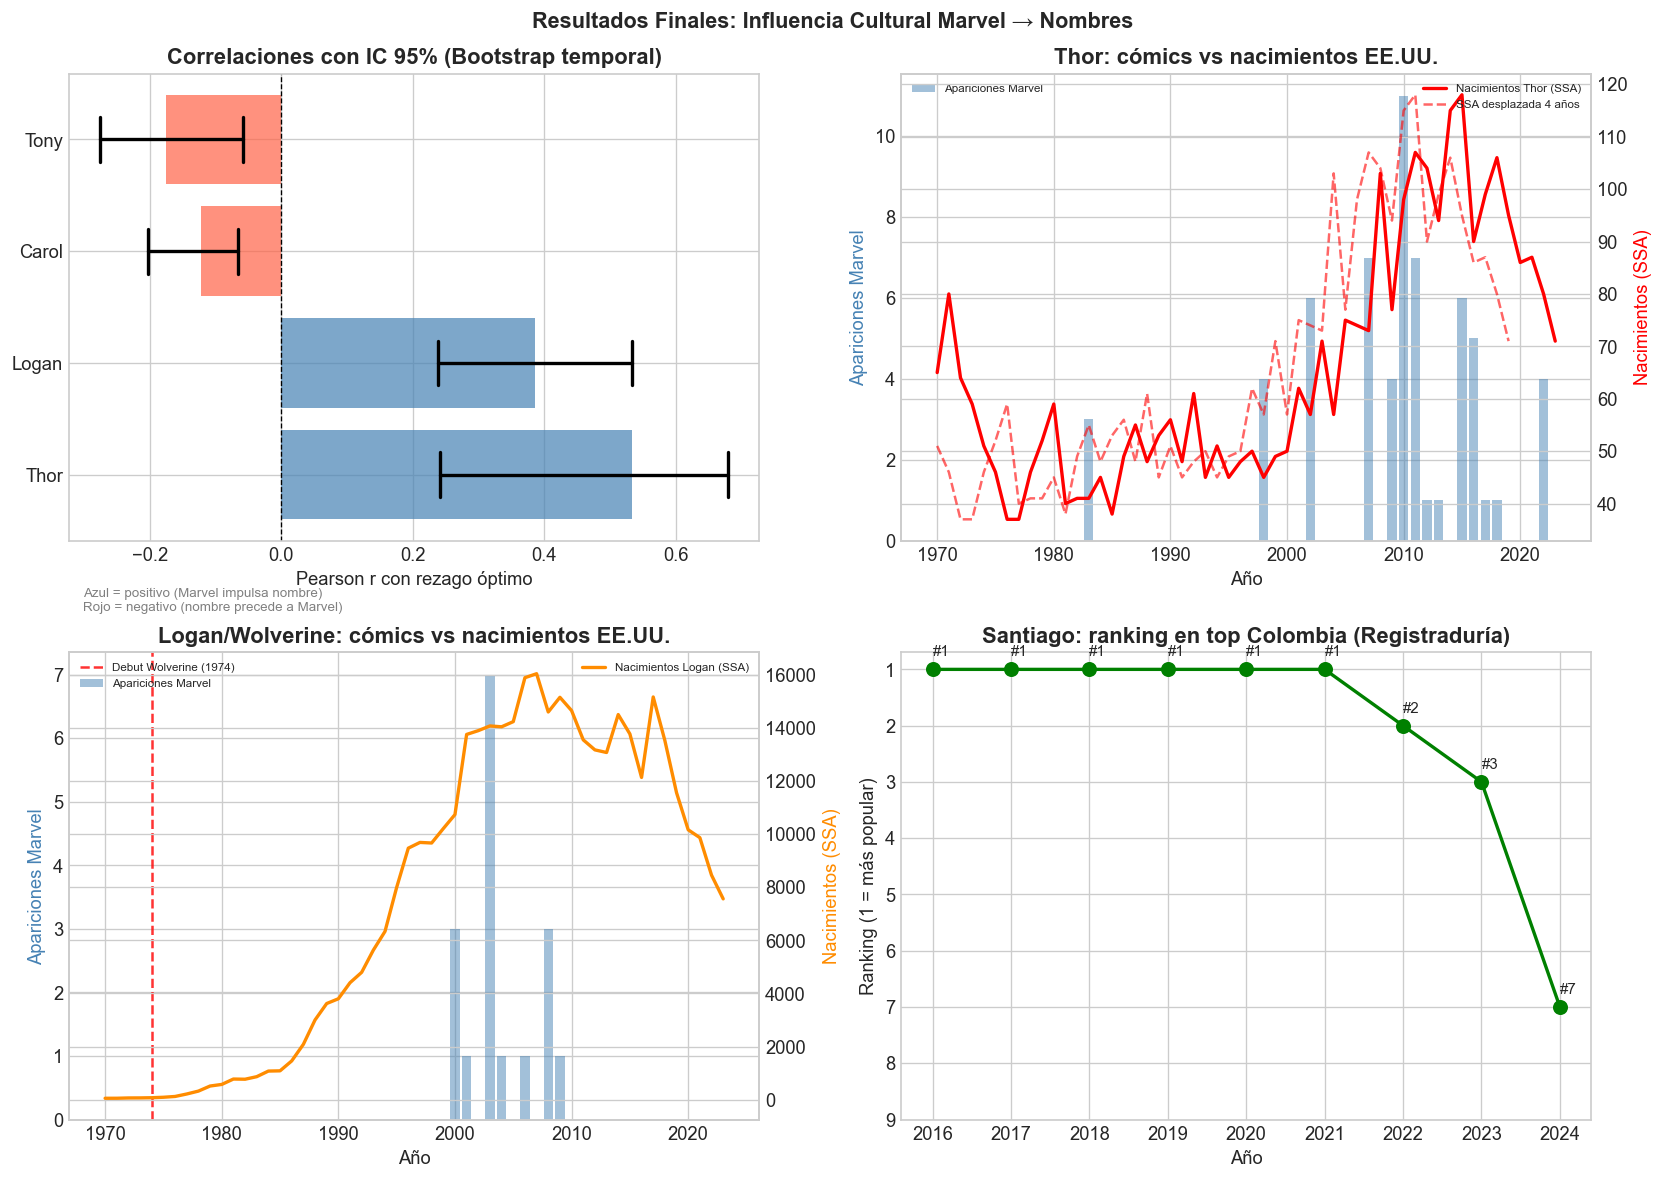

Gráficos guardados.


In [8]:
# ── Visualizaciones finales ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Gráfico 1: Bootstrap IC para nombres significativos ------
names_plot = ['Thor', 'Logan', 'Carol', 'Tony']
r_vals = [0.534, 0.386, -0.122, -0.175]
ic_low  = [0.242, 0.238, -0.202, -0.275]
ic_high = [0.679, 0.533, -0.066, -0.058]
colors  = ['steelblue', 'steelblue', 'tomato', 'tomato']

ax = axes[0, 0]
for i, (n, r, lo, hi, c) in enumerate(zip(names_plot, r_vals, ic_low, ic_high, colors)):
    ax.barh(n, r, color=c, alpha=0.7)
    ax.plot([lo, hi], [n, n], 'k-', linewidth=2)
    ax.plot([lo, lo], [i-0.2, i+0.2], 'k-', linewidth=2)
    ax.plot([hi, hi], [i-0.2, i+0.2], 'k-', linewidth=2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlaciones con IC 95% (Bootstrap temporal)', fontweight='bold')
ax.set_xlabel('Pearson r con rezago óptimo')
ax.text(0.02, -0.15, 'Azul = positivo (Marvel impulsa nombre)\nRojo = negativo (nombre precede a Marvel)',
        transform=ax.transAxes, fontsize=8, color='gray')

# --- Gráfico 2: Thor apariciones vs nacimientos ---------------
ax2 = axes[0, 1]
thor_marvel = (
    marvel_by_year[marvel_by_year['first_name'].str.lower() == 'thor']
    .groupby('year')['appearances'].sum()
    .reindex(range(1970, 2024), fill_value=0)
)
thor_ssa = get_ssa_name_freq_by_year(ssa_df, 'Thor').reindex(range(1970, 2024), fill_value=0)
thor_ssa_shifted = thor_ssa.shift(-4)

ax2b = ax2.twinx()
ax2.bar(thor_marvel.index, thor_marvel.values, alpha=0.5, color='steelblue', label='Apariciones Marvel')
ax2b.plot(thor_ssa.index, thor_ssa.values, 'r-', linewidth=2, label='Nacimientos Thor (SSA)')
ax2b.plot(thor_ssa_shifted.index, thor_ssa_shifted.values, 'r--', linewidth=1.5,
          alpha=0.6, label='SSA desplazada 4 años')
ax2.set_title('Thor: cómics vs nacimientos EE.UU.', fontweight='bold')
ax2.set_xlabel('Año')
ax2.set_ylabel('Apariciones Marvel', color='steelblue')
ax2b.set_ylabel('Nacimientos (SSA)', color='red')
ax2.legend(loc='upper left', fontsize=7)
ax2b.legend(loc='upper right', fontsize=7)

# --- Gráfico 3: Logan apariciones vs nacimientos --------------
ax3 = axes[1, 0]
logan_marvel = (
    marvel_by_year[marvel_by_year['first_name'].str.lower() == 'logan']
    .groupby('year')['appearances'].sum()
    .reindex(range(1970, 2024), fill_value=0)
)
logan_ssa = get_ssa_name_freq_by_year(ssa_df, 'Logan').reindex(range(1970, 2024), fill_value=0)

ax3b = ax3.twinx()
ax3.bar(logan_marvel.index, logan_marvel.values, alpha=0.5, color='steelblue', label='Apariciones Marvel')
ax3b.plot(logan_ssa.index, logan_ssa.values, 'darkorange', linewidth=2, label='Nacimientos Logan (SSA)')
ax3.axvline(1974, color='red', linestyle='--', alpha=0.8, label='Debut Wolverine (1974)')
ax3.set_title('Logan/Wolverine: cómics vs nacimientos EE.UU.', fontweight='bold')
ax3.set_xlabel('Año')
ax3.set_ylabel('Apariciones Marvel', color='steelblue')
ax3b.set_ylabel('Nacimientos (SSA)', color='darkorange')
ax3.legend(loc='upper left', fontsize=7)
ax3b.legend(loc='upper right', fontsize=7)

# --- Gráfico 4: Santiago en Colombia por año ------------------
ax4 = axes[1, 1]
santiago_rank = colombia_df[colombia_df['name_norm'].str.lower() == 'santiago'].sort_values('year')
ax4.plot(santiago_rank['year'], santiago_rank['rank'], 'go-', linewidth=2, markersize=8)
ax4.invert_yaxis()
ax4.set_title('Santiago: ranking en top Colombia (Registraduría)', fontweight='bold')
ax4.set_xlabel('Año')
ax4.set_ylabel('Ranking (1 = más popular)')
ax4.set_xticks(santiago_rank['year'])
ax4.set_yticks(range(1, 10))
for _, row in santiago_rank.iterrows():
    ax4.annotate(f"#{int(row['rank'])}", (row['year'], row['rank']),
                 textcoords='offset points', xytext=(0, 8), fontsize=9)

plt.suptitle('Resultados Finales: Influencia Cultural Marvel → Nombres',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig_resultados_finales.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos guardados.')